# ResNet-18 (Naive — Frozen Backbone)

In [ ]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [2]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('data_new/splits/train.csv')

num_melanoma = (train_df['label'] == 1).sum()   # melanoma in CSV (label=1)
num_nevus = (train_df['label'] == 0).sum()      # nevus in CSV (label=0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Positive weight: tensor([8.1117], device='cuda:0')


In [5]:
best_val_f2 = 0.0

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_recalls = []
val_recalls = []
train_f2s = []
val_f2s = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), 'models/resnet_naive_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.8210, Acc: 0.7318, Recall: 0.8312, F2: 0.5849 | Val Loss: 0.8054, Acc: 0.7609, Recall: 0.8475, F2: 0.6281
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.6487, Acc: 0.8058, Recall: 0.8677, F2: 0.6670 | Val Loss: 0.7445, Acc: 0.7658, Recall: 0.8729, F2: 0.6462
Saved best model at epoch 2


Epoch [3/20] | Train Loss: 0.5469, Acc: 0.8416, Recall: 0.8997, F2: 0.7205 | Val Loss: 0.8390, Acc: 0.8661, Recall: 0.7203, F2: 0.6444


Epoch [4/20] | Train Loss: 0.4955, Acc: 0.8671, Recall: 0.9099, F2: 0.7544 | Val Loss: 1.0270, Acc: 0.8898, Recall: 0.6229, F2: 0.6000


Epoch [5/20] | Train Loss: 0.4155, Acc: 0.8876, Recall: 0.9259, F2: 0.7879 | Val Loss: 0.7603, Acc: 0.8365, Recall: 0.7839, F2: 0.6565
Saved best model at epoch 5


...

Epoch [16/20] | Train Loss: 0.1193, Acc: 0.9710, Recall: 0.9795, F2: 0.9376 | Val Loss: 1.2108, Acc: 0.8592, Recall: 0.7034, F2: 0.6264


Epoch [17/20] | Train Loss: 0.1314, Acc: 0.9711, Recall: 0.9806, F2: 0.9385 | Val Loss: 1.0346, Acc: 0.8281, Recall: 0.8305, F2: 0.6768


Epoch [18/20] | Train Loss: 0.1021, Acc: 0.9758, Recall: 0.9852, F2: 0.9490 | Val Loss: 1.7799, Acc: 0.9081, Recall: 0.5975, F2: 0.5995


Epoch [19/20] | Train Loss: 0.1261, Acc: 0.9693, Recall: 0.9749, F2: 0.9322 | Val Loss: 1.3336, Acc: 0.8735, Recall: 0.6822, F2: 0.6260


Epoch [20/20] | Train Loss: 0.0965, Acc: 0.9762, Recall: 0.9840, F2: 0.9490 | Val Loss: 1.1663, Acc: 0.8513, Recall: 0.8305, F2: 0.6995
Saved best model at epoch 20


## Plot Loss and Accuracy Curves

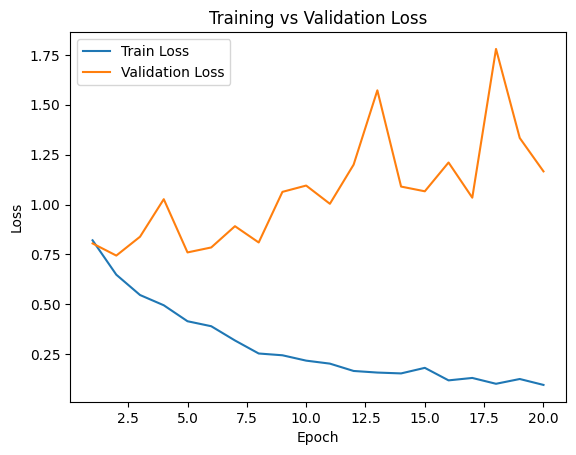

In [6]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

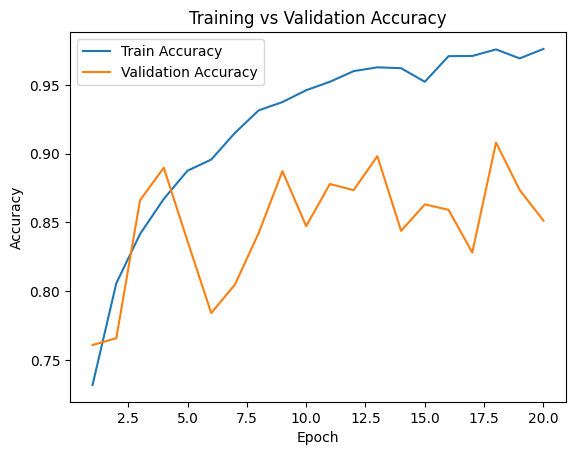

In [7]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

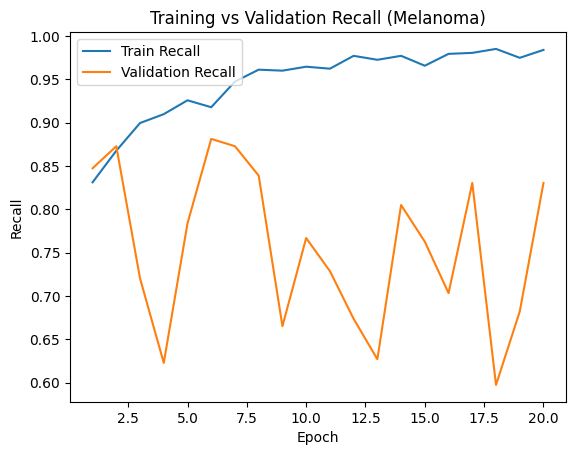

In [8]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

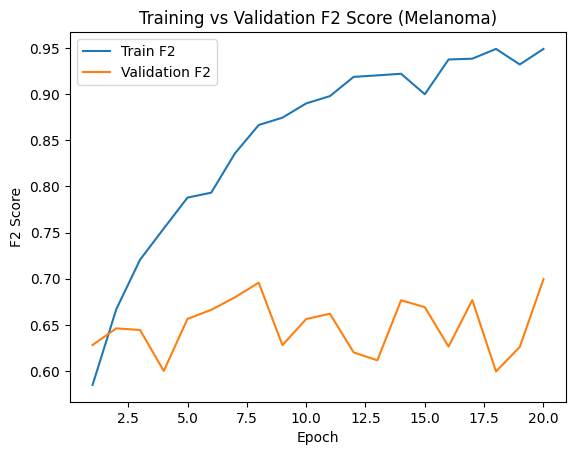

In [9]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [10]:
import numpy as np
from sklearn.metrics import fbeta_score

model.load_state_dict(torch.load('models/resnet_naive_best.pth', map_location=device))
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Best threshold: 0.57 | Val F2: 0.7060


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load('models/resnet_naive_best.pth', map_location=device))
model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [12]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[1172  168]
 [  44  127]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [13]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9638    0.8746    0.9171      1340
           1     0.4305    0.7427    0.5451       171

    accuracy                         0.8597      1511
   macro avg     0.6972    0.8087    0.7311      1511
weighted avg     0.9035    0.8597    0.8750      1511



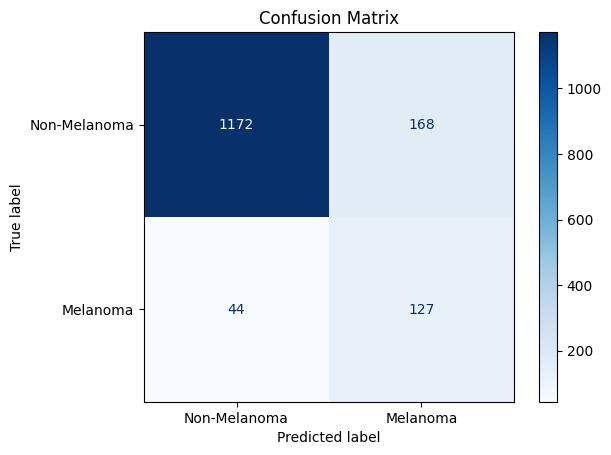

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()